# Cellpin on Whole-Transcriptome Spatial Data (10x Atera)

If you work with whole-transcriptome spatial data, you have probably already asked the obvious question: *cellpin imputes genes I don't have, but I measure ~18,000 of them, so what is left to impute?*

Cellpin provides more than gene imputation. It learns a latent representation of each cell from a deep scRNA-seq reference, producing high-resolution, biologically meaningful embeddings while simultaneously denoising measured gene expression. As a result, cells are embedded by their underlying transcriptional state rather than technical sampling noise (e.g. missegmentation, batch effects, gene dropout etc.), improving separation of cell populations and revealing finer cellular structure. Importantly, these improvements are reflected not only in imputed genes but also in the measured transcriptome, demonstrating that cellpin enhances the biological signal already present in whole-transcriptome spatial data.

- **cleaner separation** of the cell types you already expect to find,
- **rare populations that PCA merges away** - here a B cell island sitting inside 10x's own "T Lymphocytes" annotation, and a clean CD8A / FOXP3 T cell split,
- and, most importantly, **none of this is an imputation artifact**. We show each population in the *measured* counts, not only the imputed ones. The signal was in the raw data all along; the PCA embedding simply had no way to surface it.

Cellpin therefore helps you discover biology hidden in your data, not only with limited gene panels (e.g. Xenium) but also emerging whole transcriptome spatial transcriptomics data!

**Data**

- **Spatial** - 10x Atera whole-transcriptome FFPE human breast cancer: 170,057 cells x 18,028 genes, plus the expert cell-group annotation that ships with the sample.
- **Reference** - Chen et al. Human Breast Single-Cell Atlas (HBSCA), from CZ CELLxGENE: 621,200 cells, 29 classes in `cell_type`, 8 constituent studies in `batch`.

We train on 4,000 highly variable genes selected from the reference. For production work you would want to put more thought into feature selection; we keep it deliberately plain here to show that even the naive choice works well.

**Before running:** point the paths in *Configuration* at your own files.

## Setup

In [1]:
# Reading a raw Atera output folder needs spatialdata_io, which is not a cellpin dependency.
# If it is not in your environment yet, uncomment the line below:
# !pip install spatialdata_io

In [2]:
import cellpin
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata_io
import torch
from scipy.stats import median_abs_deviation

## Configuration

Everything you need to change lives in this cell.

In [3]:
# ---- Data paths (update these) ----
ATERA_PATH      = "/data/atera_breast/unzipped"
ATLAS_PATH      = "/data/scRNA/Breast/Chen_HBSCA_all_CZI/7cdea341-ca7a-40fd-8192-b8ecb2d7b91e.h5ad"
ANNOTATION_PATH = "/data/atera_breast/WTA_Preview_FFPE_Breast_Cancer_cell_groups.csv"
SAMPLE_NAME     = "ATERA_FFPE_Breast_Cancer"

# ---- QC ----
# Deliberately light-touch: enough to drop empty and blown-out segmentations, no more.
MIN_GENES       = 100
MIN_COUNTS      = 250
NORM_TARGET_SUM = 10_000

# ---- Feature selection ----
N_HVG_ATLAS     = 4_000

# ---- Model / training ----
LAYER            = "counts"   # raw integer counts live here in both objects
BATCH_KEY        = "batch"    # the atlas's 8 source studies
PRETRAIN_EPOCHS  = 50
TRAIN_EPOCHS     = 60
BATCH_SIZE       = 1024       # large atlas -- see best_practices.md
NB_COUNT_SAMPLES = 20
MC_SAMPLES       = 1          # Since we mainly care about embeddings, no need for Markov-Chains here, speeds up imputation
MASK_FRACTION    = 0.0        # Since we don't do Markov-based imputation, we set mask fraction to 0.0 for the single forward pass


# ---- Downstream clustering ----
LEIDEN_RES      = 1.0

## Helper functions

Standard scanpy QC boilerplate, nothing cellpin-specific. Skip ahead if you already have a filtered spatial object.

In [4]:
def calculate_quality_metrics(data):
    data.var["mt"] = data.var_names.str.startswith("MT-")
    data.var["ribo"] = data.var_names.str.startswith(("RPS", "RPL"))
    data.var["hb"] = data.var_names.str.contains("^Hb[^(p)]")
    sc.pp.calculate_qc_metrics(data, qc_vars=["mt", "ribo", "hb"], inplace=True)
    print("Median genes by counts:", np.median(data.obs["n_genes_by_counts"]))


def is_outlier(data, metric: str, nmads: int):
    M = data.obs[metric]
    return (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )


def outlier_per_sample(data, sample):
    print(f"Cells in {sample}: {data.shape[0]}")
    data.obs["log1p_total_counts_outlier"] = is_outlier(data, "log1p_total_counts", 5) | (
        data.obs["total_counts"] < MIN_COUNTS
    )
    data.obs["log1p_n_genes_by_counts_outlier"] = is_outlier(data, "log1p_n_genes_by_counts", 4)
    data.obs["pct_counts_in_top_50_genes_outlier"] = is_outlier(data, "pct_counts_in_top_50_genes", 5)
    data.obs["mt_outlier"] = is_outlier(data, "pct_counts_mt", 3) | (data.obs["pct_counts_mt"] > 20)
    outlier_cols = [c for c in data.obs.columns if c.endswith("_outlier")]
    data.obs["outlier"] = data.obs[outlier_cols].any(axis=1)
    print(f"Outlier cells flagged: {data.obs['outlier'].sum()}")
    return data

## 1. Load the spatial data

We switch off everything except the cell x gene table and the coordinates. Transcript locations, morphology images and boundary polygons are not used by cellpin, and skipping them avoids reading tens of GB you would never touch.

Any `AnnData` or `SpatialData` object works from here on. This is just the shortest route from a raw output folder to something we can train on.

In [5]:
sdata = spatialdata_io.xenium(
    ATERA_PATH,
    transcripts=False,
    morphology_mip=False,
    morphology_focus=False,
    aligned_images=False,
    cells_labels=False,
    nucleus_labels=False,
    cells_boundaries=False,
    nucleus_boundaries=False,
)
atera_adata = sdata.tables["table"]
print(atera_adata)

AnnData object with n_obs × n_vars = 170057 × 18028
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


## 2. QC and preprocessing

Basic filtering only. The point of this notebook is the embedding, not the QC.

We keep two things around: raw counts in `layers["counts"]`, which is what cellpin trains on, and a log1p-normalised layer in `layers["log1p_norm"]`, which is what we plot measured expression from later. Keeping the measured layer intact matters here, because the whole argument in section 8 rests on being able to go back to it.

In [6]:
atera_adata.obs["sample"] = SAMPLE_NAME
atera_adata.var_names_make_unique()

sc.pp.filter_cells(atera_adata, min_genes=MIN_GENES)
calculate_quality_metrics(atera_adata)
print(f"Cells before outlier removal: {atera_adata.shape[0]}")

atera_adata = outlier_per_sample(atera_adata, SAMPLE_NAME)
atera_adata = atera_adata[~atera_adata.obs["outlier"]]
atera_adata = atera_adata[atera_adata.obs["total_counts"] > MIN_COUNTS].copy()
print(f"Cells after filtering: {atera_adata.shape[0]}")
print(f"Count range: {atera_adata.obs['total_counts'].min():.0f} - {atera_adata.obs['total_counts'].max():.0f}")

# Store raw counts, then add a log1p-normalised layer for plotting measured expression
atera_adata.layers["counts"] = atera_adata.X.copy()
scaled_counts = sc.pp.normalize_total(atera_adata, target_sum=NORM_TARGET_SUM, inplace=False)
atera_adata.layers["log1p_norm"] = sc.pp.log1p(scaled_counts["X"], copy=True)
atera_adata.X = atera_adata.layers["log1p_norm"]

Median genes by counts: 1556.0
Cells before outlier removal: 168506
Cells in ATERA_FFPE_Breast_Cancer: 168506
Outlier cells flagged: 14948
Cells after filtering: 153558
Count range: 257 - 26078


## 3. Load the scRNA-seq reference

The HBSCA object keeps raw counts in `.raw.X` and log1p-normalised values in `.X`, so we lift the counts into a named layer to match what `setup_data` expects.

In [7]:
atlas = sc.read_h5ad(ATLAS_PATH)
atlas.layers["counts"] = atlas.raw.X
print(atlas)

AnnData object with n_obs × n_vars = 621200 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'
    layers: 'counts'


## 4. Feature selection

Pick HVGs on the reference, then intersect them with what Atera actually measured. Reference HVGs that are absent from the spatial data are still part of the model, they just end up imputed rather than measured, which is what lets the two gene spaces line up.

As mentioned up top, a more careful and biology-aware gene (and spatial sample-aware) selection will very likely beat a flat top-4,000 HVG call. This one is deliberately unremarkable and it still works.

In [8]:
# HVG selection on the reference, aware of the atlas's batch structure
sc.pp.highly_variable_genes(atlas, n_top_genes=N_HVG_ATLAS, batch_key=BATCH_KEY)
hvg_genes = atlas.var["feature_name"][atlas.var["highly_variable"]]

atlas_hvg = atlas[:, atlas.var["highly_variable"]].copy()
atlas_hvg.var_names = atlas_hvg.var["feature_name"].astype(str)
atlas_hvg.var_names_make_unique()
print(f"HVGs selected from atlas: {len(hvg_genes)}")

HVGs selected from atlas: 4000


In [9]:
# Restrict the training panel to genes the spatial data actually measured
hvg_genes_train = [g for g in hvg_genes if g in atera_adata.var_names]
n_missing = len(hvg_genes) - len(hvg_genes_train)
print(f"{n_missing} atlas HVGs absent from the Atera panel; using {len(hvg_genes_train)}")

atera_hvg = atera_adata[:, hvg_genes_train].copy()
print(f"Final shared training panel: {atera_hvg.shape[1]} genes")

631 atlas HVGs absent from the Atera panel; using 3369
Final shared training panel: 3369 genes


## 5. Train cellpin

`setup_data` aligns the two gene spaces and reports the split between measured (panel) and imputed genes. Training then runs in two stages: a full-gene VAE on the reference, followed by distillation of a panel-only encoder against it.

`batch_key="batch"` lets the model absorb the differences between the atlas's 8 source studies instead of baking them into the latent space.

In [10]:
sc_dataset, sp_dataset = cellpin.pp.setup_data(
    atlas_hvg, atera_hvg, layer=LAYER, batch_key=BATCH_KEY,
)

model = cellpin.CellPin(sc_dataset)
model.fit(
    sc_dataset,
    pretrain_epochs=PRETRAIN_EPOCHS,
    train_epochs=TRAIN_EPOCHS,
    batch_size=BATCH_SIZE,
)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :  621,200 cells  ×    4,000 genes
[cellpin.pp.setup] st_adata :  153,558 cells  ×    3,369 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] Panel    : 3,369 genes overlap (100.0% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 4,000 genes total in sc space (631 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 621,200 cells, 4,000 genes total, 3,369 panel genes
[cellpin.pp.setup] st_dataset: 153,558 cells, 3,369 panel genes


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

A quick sanity check on training. Note that this plots **Stage 2 only**, the distillation phase, and that a flat
or slightly shaky curve here is normal rather than a warning sign, see
[Best Practices](../best_practices.md#reading-the-loss-curves).

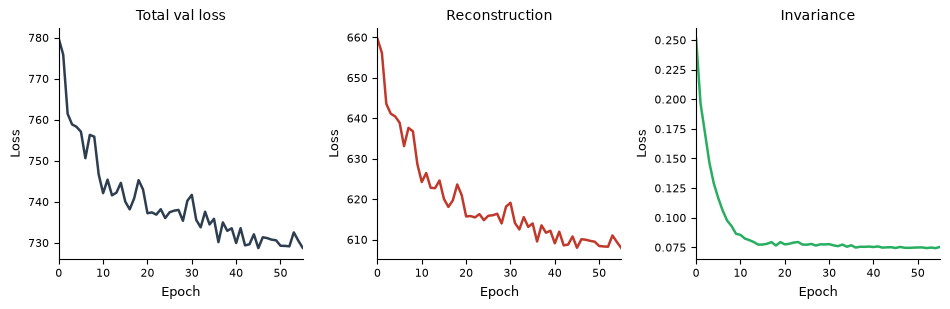

In [11]:
model.pl.losses()

## 6. Embed and impute the spatial cells

A single pass over the spatial data gives us both things we need:

- `obsm["X_cellpin"]` - the latent embedding, which is what the rest of this notebook is about
- `layers["imputed"]` and `layers["imputed_norm"]` - denoised expression across the full 4,000-gene reference space

`area_key="cell_area"` normalises by segmented cell area rather than library size, which is the more sensible correction when cell size varies with segmentation quality instead of biology. `return_int=True` returns a genuinely count-like denoised matrix, see [Best Practices](../best_practices.md).

In [13]:
dl_sp = torch.utils.data.DataLoader(sp_dataset, batch_size=BATCH_SIZE, shuffle=False)

sp_embedded = model.impute(
    dl_sp,
    obs_adata=atera_hvg,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=NB_COUNT_SAMPLES,
    mask_fraction=MASK_FRACTION,
    mc_samples=MC_SAMPLES,
    return_int=True,
)
print(sp_embedded)

Embedding and imputing cells (MC, 1 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 631 gene(s) absent from obs_adata layers with 0
AnnData object with n_obs × n_vars = 153558 × 4000
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'log1p_total_counts_outlier', 'log1p_n_genes_by_counts_outlier', 'pct_counts_in_top_50_genes_outlier'

## 7. Two embeddings, the same cells

Everything below compares two representations of the exact same 153,558 cells:

| | how cells get positioned |
|---|---|
| **cellpin** | the latent embedding `X_cellpin`, learned jointly with the reference |
| **PCA baseline** | PCA on log1p-normalised measured counts, the standard pipeline, no reference involved |

Same cells, same measured counts, same Leiden resolution. The only thing that changes is the space the neighbourhood graph is built in.

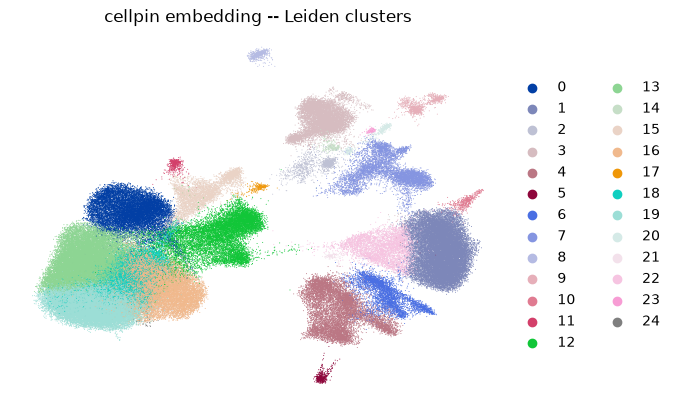

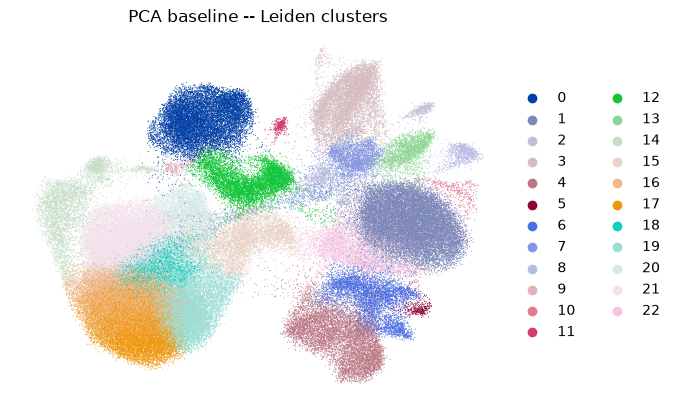

In [18]:
# cellpin embedding
sc.pp.neighbors(sp_embedded, use_rep="X_cellpin")
sc.tl.umap(sp_embedded, spread=0.5, min_dist=0.5)
sc.tl.leiden(sp_embedded, resolution=LEIDEN_RES, flavor="igraph")

# PCA baseline on the measured counts
sc.pp.pca(atera_hvg)
sc.pp.neighbors(atera_hvg)
sc.tl.umap(atera_hvg, spread=0.5, min_dist=0.5)
sc.tl.leiden(atera_hvg, resolution=LEIDEN_RES, flavor="igraph")

sc.pl.umap(sp_embedded, color="leiden", size=2, title="cellpin embedding -- Leiden clusters", frameon=False)
sc.pl.umap(atera_hvg, color="leiden", size=2, title="PCA baseline -- Leiden clusters", frameon=False)

## 8. Rare populations, and what the PCA baseline misses

10x ships an expert cell-group annotation with this sample, which gives us an independent reference point to check against. We start from the cells annotated as **T Lymphocytes** and look at what is actually inside that group.

The pattern in both examples below is the same, and it is the part that matters:

1. In PCA space the population is smeared across a region. You would never cluster it out.
2. In the cellpin embedding it separates cleanly.
3. **The separation is visible in the measured counts, not only in the imputed ones.** If this were the model hallucinating structure, the raw counts would not cooperate. They do.

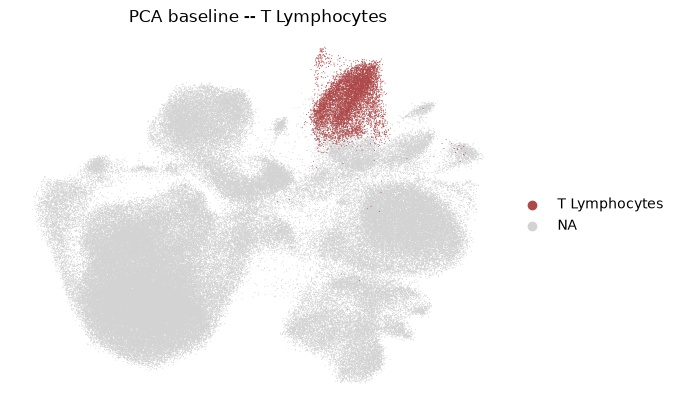

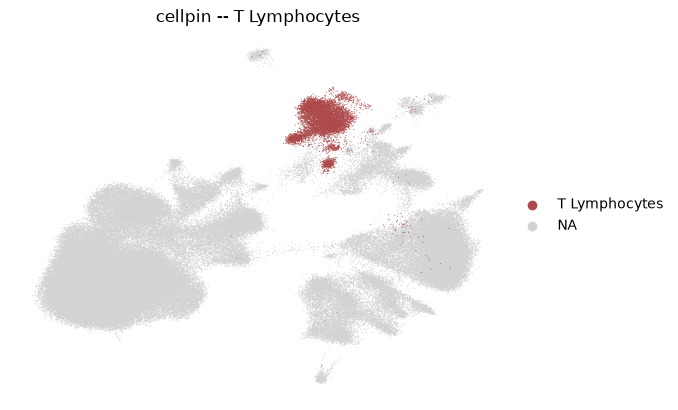

In [15]:
annot = pd.read_csv(ANNOTATION_PATH)
annot_map = annot.set_index("cell_id")["group"]

sp_embedded.obs["cell_group"] = annot_map.loc[sp_embedded.obs_names].values
atera_hvg.obs["cell_group"] = annot_map.loc[atera_hvg.obs_names].values

sc.pl.umap(atera_hvg, color="cell_group", groups=["T Lymphocytes"], size=2, frameon=False,
           title="PCA baseline -- T Lymphocytes")
sc.pl.umap(sp_embedded, color="cell_group", groups=["T Lymphocytes"], size=2, frameon=False,
           title="cellpin -- T Lymphocytes")

### 8.1 B cells hiding inside "T Lymphocytes"

`MS4A1` (CD20) is a B cell marker. It has no business being expressed in T Lymphocytes. Below it is plotted three ways: measured counts on the PCA baseline, measured counts on the cellpin embedding, and imputed counts on the cellpin embedding.

In PCA space the `MS4A1`-positive cells are scattered through the T cell region with nothing to set them apart. On the cellpin embedding they collapse into their own island, and they do so **in the measured counts**. That is what tells you this is a real, mis-annotated B cell population rather than something the model invented.

PCA embedding


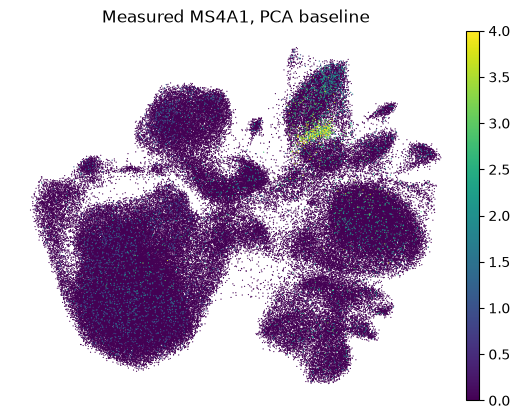

cellpin embedding


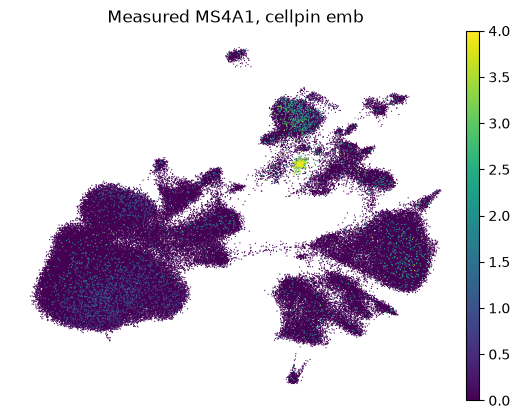

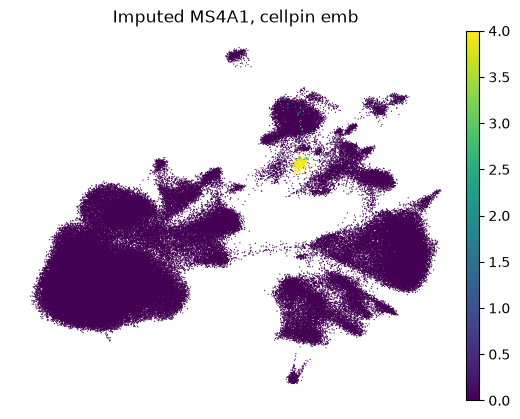

In [21]:
print("PCA embedding")
sc.pl.umap(atera_hvg, color=["MS4A1"], layer="log1p_norm", size=3, vmax=4, frameon=False,
           title="Measured MS4A1, PCA baseline")

print("cellpin embedding")
sc.pl.umap(sp_embedded, color=["MS4A1"], layer="log1p_norm", size=3, vmax=4, frameon=False,
           title="Measured MS4A1, cellpin emb")
sc.pl.umap(sp_embedded, color=["MS4A1"], layer="imputed_norm", size=3, vmax=4, frameon=False,
           title="Imputed MS4A1, cellpin emb")

### 8.2 Cytotoxic versus regulatory T cells

Same idea, one level finer. `CD8A` marks cytotoxic T cells and `FOXP3` marks regulatory T cells: two populations with very different implications for a tumour sample, and two populations the PCA baseline gives you no way to tell apart. Looking at PCA space alone you could reasonably conclude this sample contains no `FOXP3`-positive cells at all.

They are there, and again, they are there in the measured counts.

PCA embedding


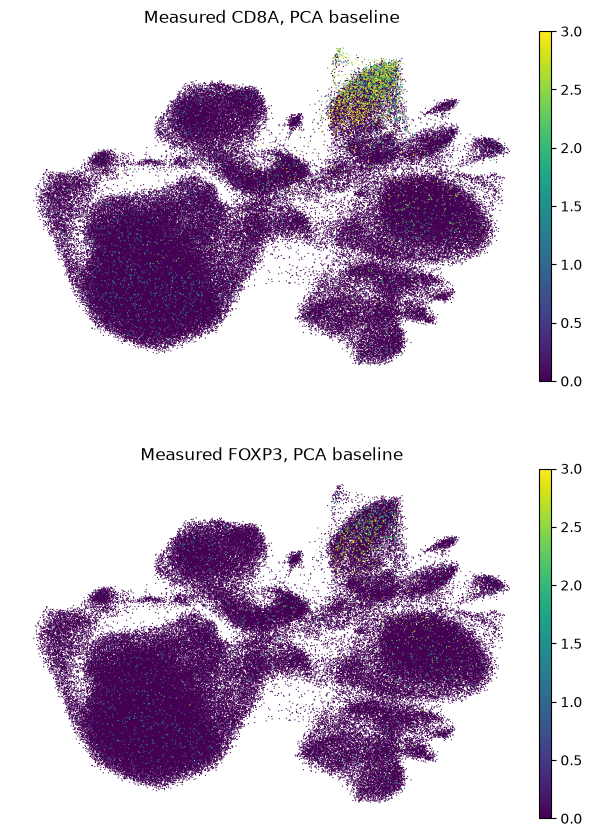

cellpin embedding


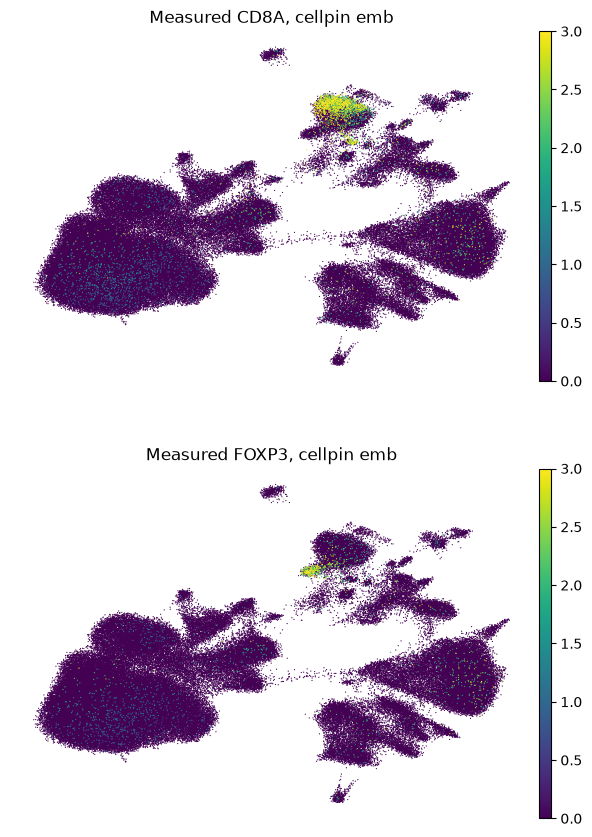

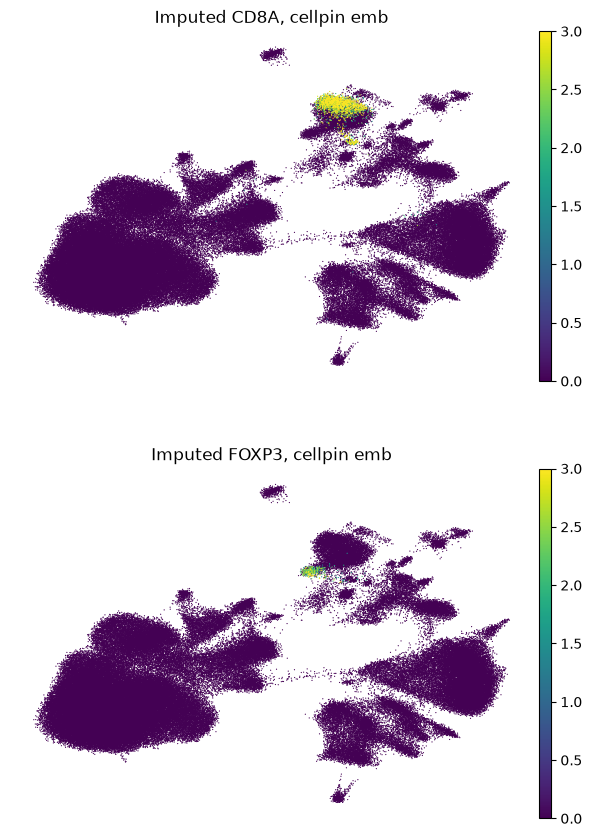

In [22]:
tgenes = ["CD8A", "FOXP3"]
print("PCA embedding")
sc.pl.umap(atera_hvg, color=tgenes, layer="log1p_norm", size=3, ncols=1, vmax=3, frameon=False,
           title=[f"Measured {gene}, PCA baseline" for gene in tgenes])

print("cellpin embedding")
sc.pl.umap(sp_embedded, color=tgenes, layer="log1p_norm", size=3, ncols=1, vmax=3, frameon=False,
           title=[f"Measured {gene}, cellpin emb" for gene in tgenes])
sc.pl.umap(sp_embedded, color=tgenes, layer="imputed_norm", size=3, ncols=1, vmax=3, frameon=False,
           title=[f"Imputed {gene}, cellpin emb" for gene in tgenes])

## Takeaways

Whole-transcriptome coverage solves the "which genes" problem. It does not solve the "how confidently do I know this cell's state" problem, and that second one is what determines what you can actually cluster and annotate.

- Cellpin's embedding is useful on Atera data **independently of imputation**. Even if you never look at a single imputed gene, the latent space is a better place to run neighbours, Leiden and UMAP than PCA on measured counts.
- Rare populations that PCA dissolves into their neighbours come back out cleanly. Here that meant a mis-annotated B cell population and a cytotoxic/regulatory T cell split, both of which change how you would read this sample.
- The signal is **verifiable in the raw measured counts**, so it is not a model artifact. Cellpin did not add the biology, it arranged the cells so you could see it.
- Imputation still comes along for free. `layers["imputed"]` covers the full reference gene space and gives you usable expression for markers with too little capture depth to plot on their own.

Figure 5 of the [preprint](https://www.biorxiv.org/content/10.64898/2026.06.02.729566v1.full.pdf) goes into more detail, including the denoising side of this that we have kept out of this notebook.